# Exercise 1: Version Control

Following the instructions in order to access this assignment, you should already be a part of a team repository.

First, create a README and have all members try to add their names to it (from the main branch) at the same time, then commit and push the changes. What happens? Upload a screenshot onto your team repository.

Now resolve the merge conflict. Then commit and push the change. That's it!

# Exercise 2: Fix this Code

This is a simple exercise meant to elucidate benefits of decomposing code. Here, we consider reading in and cleaning a dataset to prepare it for analysis.

### Branching and Folder Structure

For ***this*** exercise, first have each member of your team create their own branch. Each team member should individually complete this exercise in their own branch. When you have finished, submit pull requests to review each team members' code and merge the best solution to the `main` branch.


In this case, we are working with data from [Huang et al. (2022)](https://arxiv.org/pdf/2109.00881.pdf) that contains car characteristics and sales in the UK. Below is an example of code to read and clean a dataset on car characteristics and sales that does not adhere well to many of the principles we discussed in lecture 1.

In [1]:
## bad code:
import os
import numpy as np
import pandas as pd
import seaborn as sns


# load data
car_data_path = "data"
prices = (
    pd.read_csv(os.path.join(car_data_path, "Price_table.csv"))
    .rename(columns=str.lower)
    .rename(columns={"genmodel_id": "id", "maker": "make", "genmodel": "model"})
    .drop(columns=["make", "model"])
)
sales = (
    pd.read_csv(os.path.join(car_data_path, "Sales_table.csv"))
    .rename(columns=str.lower)
    .rename(columns={"genmodel_id": "id", "maker": "make", "genmodel": "model"})
    # pivot wide to long
    .melt(id_vars=["make", "model", "id"], var_name="year", value_name="sales")
)

# fix dtype
sales["year"] = sales["year"].astype("int64")

# remove all caps
sales["make"] = sales["make"].str.title()
sales["model"] = sales["model"].str.title()

# add yearly market shares
sales["shares"] = (
    sales
    .groupby("year", group_keys=False)
    .apply(lambda x: 100 * x["sales"] / np.sum(x["sales"]))
)

# combine prices and shares data
df = pd.merge(sales, prices, how="left", on=["id", "year"])


df = df.query("year >= 2010 and year <= 2020")
df

domestic_makes = [
    "Bentley", "Jaguar", "McLaren", "MG",
    "Rolls-Royce", "Vauxhall", "Aston Martin",
    "Land Rover", "Lotus", "MINI"
]

df = df.assign(
    domestic = lambda x: np.where(x["make"].notna(), x["make"].isin(domestic_makes), None)
)
df

,make,model,id,year,sales,shares,entry_price,domestic
0,Abarth,Abarth 124,2_1,2020,0,0.000000,NaN,False
1,Abarth,Abarth 500,2_2,2020,0,0.000000,NaN,False
2,Abarth,Abarth 595,2_4,2020,2144,0.140120,NaN,False
3,Abarth,Abarth 695,2_6,2020,45,0.002941,NaN,False
4,Abarth,Abarth Punto,2_9,2020,0,0.000000,NaN,False
...,...,...,...,...,...,...,...,...
8498,Volvo,Volvo Xc40,96_20,2010,0,0.000000,NaN,False
8499,Volvo,Volvo Xc60,96_16,2010,4548,0.271683,26290.0,False
8500,Volvo,Volvo Xc70,96_17,2010,1447,0.086439,26930.0,False
8501,Volvo,Volvo Xc90,96_18,2010,6392,0.381837,30725.0,False


1. Rewrite the above code following better coding style. Your code should be sufficiently modular, easy to read, and efficient. This may include breaking the code into functions that perform specific tasks. (Note that writing better code doesn't necessarily mean reducing the number of lines of code if the reduction comes at a cost to readability!) Ensure that your resulting dataframe is the same as the output from the code chunk above.

In [2]:
# your code:

# load data
car_data_path = "data"
prices_raw = pd.read_csv(os.path.join(car_data_path, "Price_table.csv"))
sales_raw = pd.read_csv(os.path.join(car_data_path, "Sales_table.csv"))

def clean_col_names(df):
    return (
        df
        .rename(columns=str.lower)
        .rename(
            columns={"genmodel_id": "id", "maker": "make", "genmodel": "model"}
        )
    )

def clean_prices_data(prices):
    prices = clean_col_names(prices)

    # drop unused cols
    prices = prices.drop(columns=["make", "model"])

    return prices

def add_market_shares(sales):
    # add yearly market shares
    sales["shares"] = (
        sales
        .groupby("year", group_keys=False)
        .apply(lambda x: 100 * x["sales"] / np.sum(x["sales"]))
    )
    return sales

def add_domestic_flag(sales):
    domestic_makes = [
        "Bentley", "Jaguar", "McLaren", "MG",
        "Rolls-Royce", "Vauxhall", "Aston Martin",
        "Land Rover", "Lotus", "MINI"
    ]
    sales = sales.assign(
        domestic = lambda x: x["make"].isin(domestic_makes)
    )
    return sales

def filter_sales_data(sales):
    return sales.query("year >= 2010 and year <= 2020")

def clean_sales_data(sales):
    sales = clean_col_names(sales)

    # pivot wide to long
    sales = sales.melt(
        id_vars=["make", "model", "id"],
        var_name="year",
        value_name="sales"
    )
    # fix dtype
    sales["year"] = sales["year"].astype("int64")

    # remove all caps
    sales["make"] = sales["make"].str.title()
    sales["model"] = sales["model"].str.title()

    sales = add_market_shares(sales)
    sales = add_domestic_flag(sales)
    sales = filter_sales_data(sales)

    return sales

sales = clean_sales_data(sales_raw)
prices = clean_prices_data(prices_raw)

# combine prices and shares data
df = pd.merge(sales, prices, how="left", on=["id", "year"])

The following code performs some basic exploratory data analysis by producing summary tables and plots.

In [ ]:
# top sales by model in 2019
(
    df
    .query("year == 2019")
    .groupby("model")["sales"]
    .sum()
    .reset_index()
    .sort_values("sales", ascending=False)
    .head(10)
)

In [ ]:
# top sales by model in 2020
(
    df
    .query("year == 2020")
    .groupby("model")["sales"]
    .sum()
    .reset_index()
    .sort_values("sales", ascending=False)
    .head(10)
)

In [ ]:
# top sales by make in 2020
(
    df
    .query("year == 2020")
    .groupby("make")["sales"]
    .sum()
    .reset_index()
    .sort_values("sales", ascending=False)
    .head(10)
)

In [ ]:
# best selling cars in the last decade
(
    df
    .groupby("make")["sales"]
    .sum()
    .reset_index()
    .sort_values("sales", ascending=False)
    .head(15)
)

In [ ]:
# plot sales by year for foreign and domestic makes
df_domestic = (
    df
    .groupby(["domestic", "year"])["sales"]
    .sum()
    .reset_index()
    .sort_values("sales", ascending=False)
)

sns.lineplot(df_domestic, x="year", y="sales", hue="domestic")

2. Rewrite the above code following better coding style. In particular, you should produce one function that can output any of the tables produced above depending on the arguments specified. This function should not repeat any code and will likely be only a handful of lines long.

<Axes: xlabel='year', ylabel='sales'>

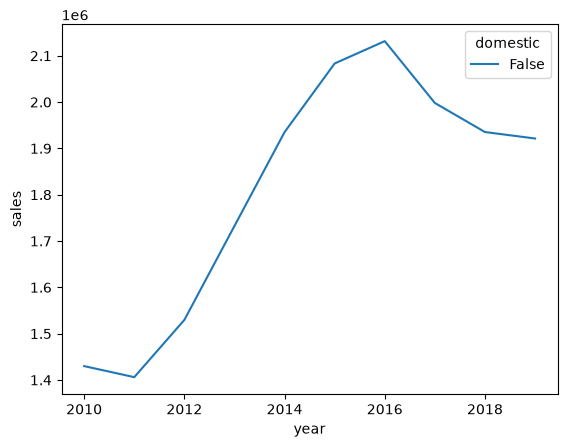

In [3]:
# your code:

def sales_by_group(df, group, filter=None, min_sales=0, top_n=10):
    if filter is not None:
        df = df.query(filter)
    df_group = (
        df
        .groupby(group)["sales"]
        .sum()
        .reset_index()
        .sort_values(by=group + ["sales"])
        .query(f"sales >= {min_sales}")
        .head(top_n)
    )
    return df_group


sales_by_group(df, group=["model"], filter="year == 2019")
sales_by_group(df, group=["model"], filter="year == 2020")
sales_by_group(df, group=["make"], filter="year == 2020")
sales_by_group(df, group=["make"])
df_domestic = sales_by_group(df, group=["domestic", "year"])
sns.lineplot(df_domestic, x="year", y="sales", hue="domestic")

# Exercise 3: Bertrand Competition with Quality Differentiation

For this exercise, feel free to work as a group on a single branch. We think it's good practice to understand how classes are set up, but if you are feeling confident about that you are welcome to use AI as you would in your own research. As always though, you need to take adequate steps to make sure any AI-generated code is actually doing what you want it to!

Two firms $A$ and $B$ compete a la Bertrand in the market to sell smartphones. The market is characterized by heterogeneity in the quality $\phi$ provided. Consumers $k$ value quality and price equally but have heterogeneous tastes, characterized by a shock $\epsilon_k$ that follows the type I extreme value distribution. There are $M$ total consumers in the market.

## Consumers and Demand
Consumer $k$'s utility of purchasing a smartphone from firm $i \in \{A, B\}$ is:

$$ U_k = f(\phi_i) + g(p_i) + \epsilon_k$$
where $$f(\phi) = a\phi - b$$ for some constants $a, b$, and
$$g(p) = -\log(1+p)$$

This is a logit discrete choice model: each consumer either purchases one single smartphone, or exercises their outside option (i.e. no purchase), which gives them utility 0. They rank the two smartphones acording to this utility, and purchase the one that they prefer (or, decide not to purchase if both utilities are negative).

A standard result in this setting (which you may have seen, and which you will see if you take the first semester of IO), is that aggregate demand for firm $i$ is given by:

$$D(p_i, \phi_i) = M \frac{\exp(f(\phi_i) +g(p_i))}{1 + \exp(f(\phi_A) + g(p_A)) + \exp(f(\phi_B) +g(p_B))}$$

## Firms and Supply
Firms decide on prices and quality to maximize profit:
$$\max_{p_i, \phi_i} (p_i - mc_i(\phi_i)) D(p_i, \phi_i)$$

Marginal cost is convex in quality and differs by firm:
$$mc_i(\phi_i) = d_i + \frac{e_i}{2} \phi_i^2$$
for some constants $d_i, e_i$.

## Equilibrium

The first-order conditions (FOC) for an interior solution for firm $i$'s profit maximization problem would be given by the following:

FOC with respect to price:
$$0 = \frac{\partial \pi_i}{\partial p_i} = 1 + g'(p_i) \frac{1+\exp(f(\phi_{-i}) +g(p_{-i}))}{1 + \exp(f(\phi_A) +g(p_A)) + \exp(f(\phi_B) +g(p_B))} [p_i - mc_i(\phi_i)]$$

FOC with respect to quality:
$$0 = \frac{\partial \pi_i}{\partial \phi_i} = -mc_i'(\phi_i) + f'(\phi_i) \frac{1+\exp(f(\phi_{-i}) +g(p_{-i}))}{1 + \exp(f(\phi_A) + g(p_A)) + \exp(f(\phi_B) + g(p_B))} [p_i - mc_i(\phi_i)]$$

where a subscript of $-i$ indicates the quality or price of the other firm.

# Solutions 

This is an example of one possible way to structure your code.

In [8]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import unittest

In [7]:
class Firm:

    def __init__(self, d, e):
        """
        Initialize a firm with given marginal cost parameters.

        Args:
            d (float): Linear component of the marginal cost.
            e (float): Quadratic component of the marginal cost.
        """
        self.d, self.e = d, e

    def marginal_cost(self, phi):
        """
        Calculate the marginal cost given the quality level.

        Args:
            phi (float): Quality level.

        Returns:
            float: Marginal cost.
        """
        return self.d + self.e / 2 * (phi ** 2)

    def deriv_mc(self, phi):
        """
        Calculate the derivative of the marginal cost with respect to quality.

        Args:
            phi (float): Quality level.

        Returns:
            float: Derivative of the marginal cost.
        """
        return self.e * phi

In [6]:
class BertrandDuopoly:

    def __init__(self, firm1, firm2, M, a, b,
                 utility_price = None, mu_price = None):
        """
        Initialize the Bertrand duopoly market with two firms.

        Args:
            firm1 (Firm): First firm in the duopoly.
            firm2 (Firm): Second firm in the duopoly.
            M (float): Total market size.
            a (float): Parameter for the utility function.
            b (float): Parameter for the utility function.
        """
        self.firm1, self.firm2 = firm1, firm2
        self.M, self.a, self.b = M, a, b

        if utility_price is None:
            utility_price = lambda p: -np.log(1.0 + p)
        if mu_price is None:
            mu_price = lambda p: -1.0 / (1.0 + p)

        
        self.utility_price, self.mu_price = utility_price, mu_price

    def utility_quality(self, phi):
        """
        Calculate the utility derived from quality.

        Args:
            phi (float): Quality level.

        Returns:
            float: Utility from the given quality level.
        """
        return self.a * phi - self.b

    def mu_quality(self, phi):
        """
        Calculate the marginal utility derived from quality.

        Args:
            phi (float): Quality level.

        Returns:
            float: Marginal utility from the given quality level.
        """
        return self.a

    
    # def utility_price(self, p):
    #     """
    #     Calculate the utility derived from price.
    #     """
    #     return -np.log(1 + p)

    # def mu_price(self, p):
    #     """
    #     Calculate the marginal utility derived from price.
    #     """
    #     return -1 / (1 + p)
    


    def demand_firm(self, p1, phi1, p2, phi2):
        """
        Calculate the demand for firm 1 based on market prices and quality levels.

        Args:
            p1 (float): Price set by firm 1.
            phi1 (float): Quality level set by firm 1.
            p2 (float): Price set by firm 2.
            phi2 (float): Quality level set by firm 2.

        Returns:
            float: Demand for firm 1.
        """
        numerator = np.exp(self.utility_quality(phi1) + self.utility_price(p1))
        return self.M * numerator / (1 + numerator + np.exp(self.utility_quality(phi2) + self.utility_price(p2)))

    def profit(self, firm, p1, phi1, p2, phi2):
        """
        Calculate the profit for a given firm based on market prices and quality levels.

        Args:
            firm (Firm): The firm for which profit is being calculated.
            p1 (float): Price set by the given firm.
            phi1 (float): Quality level set by the given firm.
            p2 (float): Price set by the competing firm.
            phi2 (float): Quality level set by the competing firm.

        Returns:
            float: Profit for the given firm.
        """
        return (p1 - firm.marginal_cost(phi1)) * self.demand_firm(p1, phi1, p2, phi2)

    def foc_duo(self, price_and_q):
        """
        Compute the first-order conditions (FOCs) for the duopoly problem.

        Args:
            price_and_q (list or np.array): Prices and quality levels [p1, p2, phi1, phi2].

        Returns:
            np.array: First-order conditions for prices and quality levels.
        """
        p1, p2 = price_and_q[0], price_and_q[1]
        phi1, phi2 = price_and_q[2], price_and_q[3]

        # Utilities
        numerator1 = np.exp(self.utility_quality(phi1) + self.utility_price(p1))
        numerator2 = np.exp(self.utility_quality(phi2) + self.utility_price(p2))
        denominator = (1 + numerator1 + numerator2)

        firm_foc1 = (p1 - self.firm1.marginal_cost(phi1)) * (1 + numerator2) / denominator * self.mu_price(p1)
        firm_foc2 = (p2 - self.firm2.marginal_cost(phi2)) * (1 + numerator1) / denominator * self.mu_price(p2)

        foc_vec = -np.inf * np.ones(4)

        # Price FOCs
        foc_vec[0] = 1 + firm_foc1
        foc_vec[1] = 1 + firm_foc2

        # Quality FOCs
        foc_vec[2] = -self.firm1.deriv_mc(phi1) + self.mu_quality(phi1) * firm_foc1 / self.mu_price(p1)
        foc_vec[3] = -self.firm2.deriv_mc(phi2) + self.mu_quality(phi2) * firm_foc2 / self.mu_price(p2)

        return foc_vec

    def equilibrium_duo(self, init=None):
        """
        Compute the equilibrium prices and quality levels for the duopoly market.

        Args:
            init (list or np.array, optional): Initial guess for prices and quality levels. Defaults to np.ones(4).

        Returns:
            tuple: Equilibrium prices, quality levels, and profits (p1, p2, phi1, phi2, profits).
        """
        if init is None:
            init = np.ones(4)

        results = opt.least_squares(self.foc_duo, init, bounds=(1e-10 * np.ones(4), np.inf * np.ones(4)))
        (p1, p2, phi1, phi2) = results.x

        # Calculate equilibrium profits
        profits = [self.profit(self.firm1, p1, phi1, p2, phi2),
                   self.profit(self.firm2, p2, phi2, p1, phi1)]

        # Return equilibrium prices, qualities, and profits
        return (p1, p2, phi1, phi2, profits)

    def plot_profits(self, firm1, p1_grid, phi1_grid, firm_fix, p_fix, phi_fix):
        """
        Plot the profits of firm 1 while keeping firm_fix's price and quality fixed.

        Args:
            firm1 (Firm): The firm for which profit is being calculated.
            p1_grid (np.array): Grid of prices for firm 1.
            phi1_grid (np.array): Grid of quality levels for firm 1.
            firm_fix (Firm): Fixed firm (firm 2).
            p_fix (float): Fixed price for firm 2.
            phi_fix (float): Fixed quality level for firm 2.

        Returns:
            np.array: Grid of profits for firm 1.
        """
        profit_grid = np.zeros((len(p1_grid), len(phi1_grid)))
        for i in range(len(p1_grid)):
            profit_grid[i, :] = self.profit(firm1, p1_grid[i], phi1_grid, p_fix, phi_fix)

        profit_grid[profit_grid < 0] = 0

        # Prepare the meshgrid
        p, qual = np.meshgrid(p1_grid, phi1_grid)

        # Plot the value function
        plt.contourf(p, qual, profit_grid.T, cmap='viridis')
        plt.xlabel('Price')
        plt.ylabel('Quality')
        plt.title(f'Profit if Other Firm Price={p_fix} and Quality={phi_fix}')
        plt.colorbar()
        plt.show()

        return profit_grid

In [9]:
# Instantiate firms and Bertrand Duopoly
firm1 = Firm(4, 2)
firm2 = Firm(3, 4)
duopoly = BertrandDuopoly(firm1, firm2, 1e7, 5, 10)

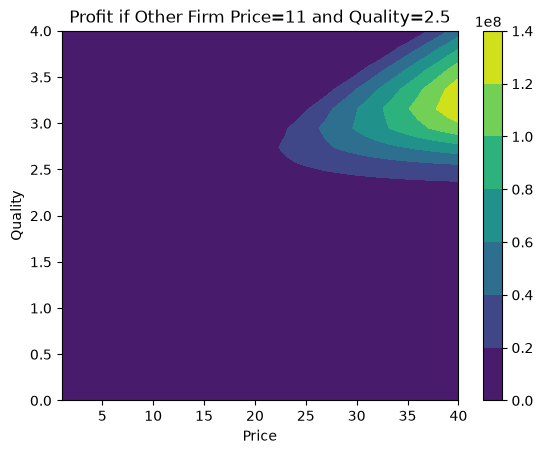

In [10]:
# Plot profit of firm B taking firm A as fixed
p1_fix = 11
phi1_fix = 2.5
p2_grid = np.linspace(1, 40, num=40)
phi2_grid = np.linspace(0, 4, num=20)
profit_firm2 = duopoly.plot_profits(firm2, p2_grid, phi2_grid, firm1, p1_fix, phi1_fix)

In [11]:
# Solve the full equilibrium based on FOCs
(p1, p2, phi1, phi2, profits) = duopoly.equilibrium_duo()
print(f"Firm 1 Price: {p1:.2f}, Quality: {phi1:.2f}, Profit: {profits[0]:.2f}")
print(f"Firm 2 Price: {p2:.2f}, Quality: {phi2:.2f}, Profit: {profits[1]:.2f}")

Firm 1 Price: 9.03, Quality: 2.03, Profit: 934997.84
Firm 2 Price: 8.08, Quality: 1.40, Profit: 56610.37


However, there's actually no finite solution here! You can see above that $\frac{\partial \pi_i}{\partial p_i}$ is strictly increasing in $p_i$ no matter what, because the second term is always greater than -1 when $g(p_i) = -\log(1+p_i)$. So there's no interior solution, and both firms will want to set $p\to\infty$. The numerical solver does give you a solution, because we're only searching in bounds. If you didn't catch this analytically, one clue is that optimal price in the countour plot above is always at the boundary, no matter how high you set it. Another is the seemingly high profits found in the equilibrium soluation above. The purpose of this is to show you that even with how good AI is at coding, sometimes you'll get a result that looks ok but doesn't actually make economic sense. Critical thinking is always necessary!

In [12]:
# Instantiate firms and Bertrand Duopoly
firm3 = Firm(4, 2)
firm4 = Firm(3, 4)
duopoly2 = BertrandDuopoly(
    firm3, firm4, 1e7, 5, 10,
    utility_price = lambda p: -p,
    mu_price = lambda p: -1
)

In [13]:
# Solve the full equilibrium based on FOCs
(p1_2, p2_2, phi1_2, phi2_2, profits_2) = duopoly2.equilibrium_duo()
print(f"Firm 1 Price: {p1_2:.2f}, Quality: {phi1_2:.2f}, Profit: {profits_2[0]:.2f}")
print(f"Firm 2 Price: {p2_2:.2f}, Quality: {phi2_2:.2f}, Profit: {profits_2[1]:.2f}")

Firm 1 Price: 11.25, Quality: 2.50, Profit: 1584.33
Firm 2 Price: 7.13, Quality: 1.25, Profit: 189.22


This time this is indeed a correct interior solution.

In [14]:
# Example of a Unit test if it passed
class TestBertrandDuopoly(unittest.TestCase):

    def setUp(self):
        self.firm1 = Firm(4, 2)
        self.firm2 = Firm(3, 4)
        self.duopoly = BertrandDuopoly(
            self.firm1, self.firm2, 1e7, 5, 10,
            utility_price = lambda p: -p,
            mu_price = lambda p: -1
        )
        self.init_value = 3 * np.ones(4)

    def test_equilibrium_duo(self):
        known_p1 = 11.25  # Example known price for firm 1
        known_p2 = 7.13  # Example known price for firm 2
        known_phi1 = 2.50  # Example known quality for firm 1
        known_phi2 = 1.25  # Example known quality for firm 2
        known_profits = [1584.33, 189.22]  # Example known profits for firms 1 and 2

        p1, p2, phi1, phi2, profits = self.duopoly.equilibrium_duo(self.init_value)

        self.assertAlmostEqual(p1, known_p1, places=2, msg="Firm 1 price not as expected")
        self.assertAlmostEqual(p2, known_p2, places=2, msg="Firm 2 price not as expected")
        self.assertAlmostEqual(phi1, known_phi1, places=2, msg="Firm 1 quality not as expected")
        self.assertAlmostEqual(phi2, known_phi2, places=2, msg="Firm 2 quality not as expected")
        self.assertAlmostEqual(profits[0], known_profits[0], places=2, msg="Firm 1 profit not as expected")
        self.assertAlmostEqual(profits[1], known_profits[1], places=2, msg="Firm 2 profit not as expected")

def run_tests():
    suite = unittest.TestLoader().loadTestsFromTestCase(TestBertrandDuopoly)
    unittest.TextTestRunner(verbosity=2).run(suite)

# Run the tests
run_tests()

test_equilibrium_duo (__main__.TestBertrandDuopoly.test_equilibrium_duo) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.008s

OK


# Submission ⭐

Now merge back any branches onto the `main` branch of your team repository from GitHub classroom. 

Congratulations you have completed the module!